In [1]:
pip install xgboost

🔄 Loading dataset...
Initial dataset: 23,078 rows

🔄 Removing nulls and duplicates...
After cleaning: 23,078 rows

🔄 Encoding target labels...
Classes: ['Major', 'Minor', 'Moderate', 'No Interaction', 'Unknown']
Train shape: (18462, 2) | Test shape: (4616, 2)

🔍 Training Multiclass XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Best Parameters:
{'xgb__subsample': 1.0, 'xgb__n_estimators': 400, 'xgb__max_depth': 8, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.8}

📊 Classification Report:
                precision    recall  f1-score   support

         Major       0.81      0.76      0.79       585
         Minor       0.63      0.21      0.32        57
      Moderate       0.81      0.84      0.82      1290
No Interaction       0.95      0.96      0.95      2211
       Unknown       0.85      0.89      0.87       473

      accuracy                           0.88      4616
     macro avg       0.81      0.73      0.75      4616
  w

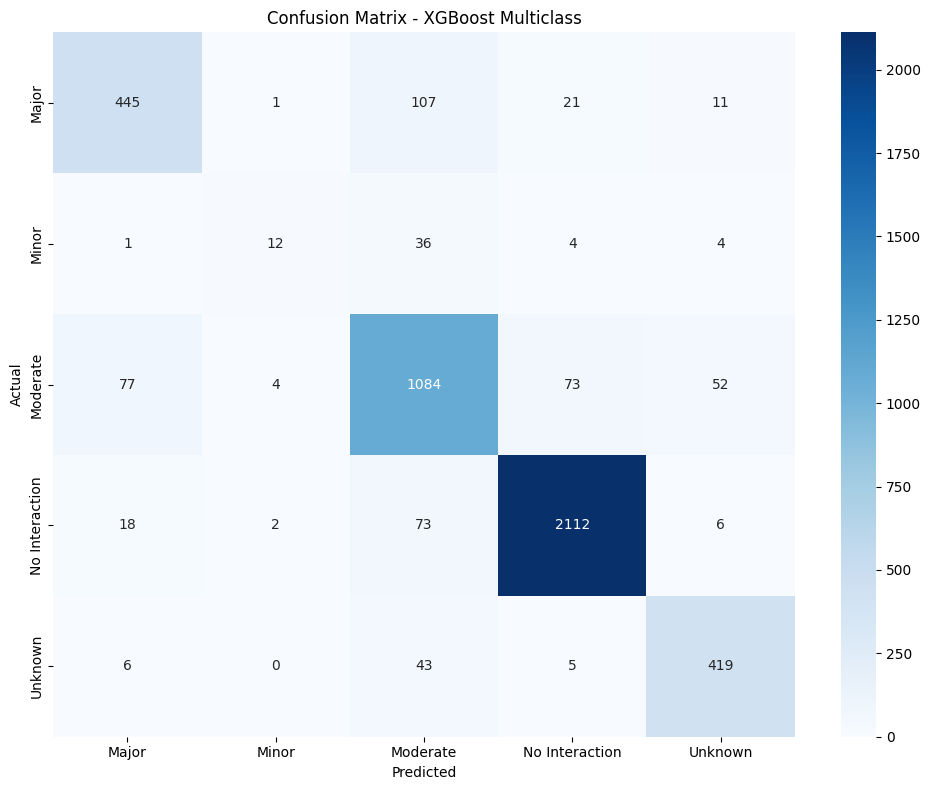

In [2]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings('ignore')

# ====================== STEP 1: LOAD DATA ======================
print("🔄 Loading dataset...")

df = pd.read_csv('DDinter_with_negatives.csv')

# Normalize drug names
df['Drug_A'] = df['Drug_A'].str.lower().str.strip()
df['Drug_B'] = df['Drug_B'].str.lower().str.strip()

print(f"Initial dataset: {len(df):,} rows")

# ====================== STEP 2: CLEANING ======================
print("\n🔄 Removing nulls and duplicates...")
df = df.dropna(subset=['Drug_A', 'Drug_B', 'Level'])
df = df.drop_duplicates()
print(f"After cleaning: {len(df):,} rows")

# ====================== STEP 3: ENCODE TARGET ======================
print("\n🔄 Encoding target labels...")

le = LabelEncoder()
df['Level_encoded'] = le.fit_transform(df['Level'])

class_names = le.classes_
print("Classes:", list(class_names))

# ====================== STEP 4: SPLIT DATA ======================
X = df[['Drug_A', 'Drug_B']]
y = df['Level_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

# ====================== STEP 5: PIPELINE ======================
pipeline = Pipeline([
    ('encoder', TargetEncoder(target_type='multiclass')),
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        objective='multi:softprob',
        num_class=len(class_names),
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

# ====================== STEP 6: RANDOM SEARCH ======================
param_dist = {
    'xgb__n_estimators': [200, 400, 600],
    'xgb__max_depth': [4, 6, 8],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0],
    'xgb__gamma': [0, 1, 5]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score='raise'
)

print("\n🔍 Training Multiclass XGBoost...")
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("\n✅ Best Parameters:")
print(random_search.best_params_)

# ====================== STEP 7: EVALUATION ======================
y_pred = best_model.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# ====================== STEP 8: CONFUSION MATRIX ======================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix - XGBoost Multiclass")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [3]:
# ====================== ADDITIONAL METRICS: Overall Precision/Recall/F1 ======================

from sklearn.metrics import precision_score, recall_score, f1_score

# Overall (macro & weighted) Precision, Recall, and F1
print("\n=== Overall Metrics (Tuned Model) ===")

# Macro = unweighted average across classes
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro    = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro        = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Macro Precision : {precision_macro:.4f}")
print(f"Macro Recall    : {recall_macro:.4f}")
print(f"Macro F1 Score  : {f1_macro:.4f}")

# Weighted = average weighted by class support (most commonly used "total" score)
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_weighted    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_weighted        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Weighted Precision : {precision_weighted:.4f}")
print(f"Weighted Recall    : {recall_weighted:.4f}")
print(f"Weighted F1 Score  : {f1_weighted:.4f}")


=== Overall Metrics (Tuned Model) ===
Macro Precision : 0.8115
Macro Recall    : 0.7305
Macro F1 Score  : 0.7496
Weighted Precision : 0.8804
Weighted Recall    : 0.8821
Weighted F1 Score  : 0.8798


In [4]:
# ====================== STEP 8: SAVE THE FULL PIPELINE ======================
# Save the complete fitted pipeline (encoder + scaler + XGB)
# This allows you to make predictions directly on new raw Drug_A / Drug_B pairs

joblib.dump(best_model, "DDinter_XGBoost_Multi.pkl")
joblib.dump(le, "xgb_label_encoder.pkl")

print("\n✅ Full pipeline saved successfully as 'DDinter_XGBoost_Multi.pkl' and label encoder as 'xgb_label_encoder.pkl' ")


✅ Full pipeline saved successfully as 'DDinter_XGBoost_Multi.pkl' and label encoder as 'xgb_label_encoder.pkl' 


In [5]:
# ====================== OVERALL METRICS (Multiclass) ======================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Micro-averaged = "overall" / global metrics (sums all TP/FP/FN across classes)
# This is what most people mean by "overall" when they don't want macro or weighted
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall    = recall_score(y_test, y_pred, average='micro')
f1        = f1_score(y_test, y_pred, average='micro')

print("\n" + "="*60)
print("📊 OVERALL METRICS (Multiclass - Micro Averaged)")
print("="*60)
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*60)

# Note: In multiclass, micro-averaged Precision = Recall = Accuracy


📊 OVERALL METRICS (Multiclass - Micro Averaged)
Accuracy  : 0.8821  (88.21%)
Precision : 0.8821
Recall    : 0.8821
F1-Score  : 0.8821
